Eigenvalues (descending):
 1: 8.187e+00
 2: 1.015e-01
 3: 3.544e-04
 4: 2.743e-04
 5: 1.353e-04
 6: 7.765e-09


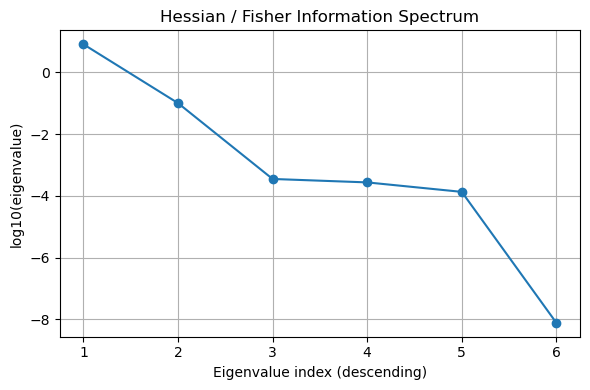


Eigenvector 1 (lambda=8.187e+00):
    k1_aa_over_CT: -0.589
            k3_CT: -0.000
               k4: -0.417
          k4prime: -0.186
               k6: +0.667
               k7: -0.000

Eigenvector 2 (lambda=1.015e-01):
    k1_aa_over_CT: -0.772
            k3_CT: +0.001
               k4: +0.274
          k4prime: +0.415
               k6: -0.395
               k7: +0.004

Eigenvector 3 (lambda=3.544e-04):
    k1_aa_over_CT: +0.233
            k3_CT: +0.000
               k4: -0.181
          k4prime: +0.874
               k6: +0.337
               k7: +0.186

Eigenvector 4 (lambda=2.743e-04):
    k1_aa_over_CT: -0.042
            k3_CT: -0.001
               k4: -0.012
          k4prime: -0.166
               k6: -0.090
               k7: +0.981
eigvals sorted (desc): [8.18676459e+00 1.01473158e-01 3.54427789e-04 2.74331701e-04
 1.35317273e-04 7.76482436e-09]
ratio largest/smallest (use smallest > 0): 1054339958.2498242
log10 span: 9.022980666082216
H diagonal: [2.90158392e+00 

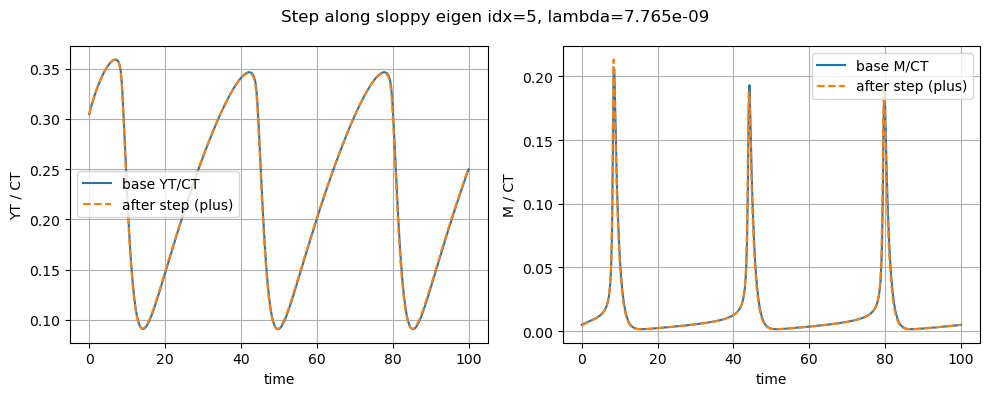

In [1]:
# Sloppiness analysis for the Tyson-like 6-state ODE example
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigh

# === Base parameters (user provided) ===
p = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# We'll analyze these parameters (drop k2 and k5_minusP; add k8_minusP and k9)
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
    #,"k8_minusP",
    #,"k9"
]
pvec = np.array([p[name] for name in param_names])
p_index = {name:i for i,name in enumerate(param_names)}
P = len(param_names)


# === model right-hand side and helper functions ===
CT = p["CT"]

def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    # derivative of F_M wrt M
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    """Compute df/dx (6x6) analytically at state x."""
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # dF/dM
    dF = dF_dM(M, p)
    J = np.zeros((6,6))
    # dC2
    J[0,0] = -p["k8_minusP"]    # d(dC2)/dC2
    J[0,1] = p["k9"]           # d(dC2)/dCP
    J[0,3] = p["k6"]           # d(dC2)/dM
    # dCP
    J[1,0] = p["k8_minusP"]
    J[1,1] = -k3*Y - p["k9"]
    J[1,4] = -k3*CP
    # dpM
    J[2,1] = k3*Y
    J[2,2] = -F_M(M, p)
    J[2,3] = -pM * dF + p["k5_minusP"]
    J[2,4] = k3*CP
    # dM
    J[3,2] = F_M(M, p)
    J[3,3] = pM * dF - p["k5_minusP"] - p["k6"]
    # dY
    k1 = p["k1_aa_over_CT"] * p['CT']
    J[4,1] = -k3 * Y
    J[4,4] = -p["k2"] - k3 * CP
    # dYP
    J[5,3] = p["k6"]
    J[5,5] = -p["k7"]
    return J

def df_dparam(x, p):
    """Compute df/dh for each parameter in param_names (returns 6 x P array).
       Now supports parameters: k1_aa_over_CT, k3_CT, k4, k4prime, k6, k7, k8_minusP, k9
    """
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # precompute pieces
    dfdh = np.zeros((6, P))
    for j,name in enumerate(param_names):
        if name == "k1_aa_over_CT":
            # k1 = k1_aa_over_CT * CT appears only in dY as +k1
            df = np.zeros(6); df[4] = p['CT']  # d(dY)/d k1_aa_over_CT = CT
            dfdh[:,j] = df
        elif name == "k3_CT":
            # k3 = k3_CT / CT
            coeff = 1.0 / p["CT"]
            df = np.zeros(6)
            df[1] = -coeff * CP * Y     # d(dCP)/d k3_CT
            df[2] =  coeff * CP * Y     # d(dpM)/d k3_CT
            df[4] = -coeff * CP * Y     # d(dY)/d k3_CT
            dfdh[:,j] = df
        elif name == "k4":
            df = np.zeros(6)
            dFdk4 = (M / p["CT"])**2
            df[2] = -pM * dFdk4   # dpM
            df[3] =  pM * dFdk4   # dM
            dfdh[:,j] = df
        elif name == "k4prime":
            df = np.zeros(6)
            dFdk4p = 1.0
            df[2] = -pM * dFdk4p
            df[3] =  pM * dFdk4p
            dfdh[:,j] = df
        elif name == "k6":
            df = np.zeros(6)
            df[0] = M          # d(dC2)/d k6 = M
            df[3] = -M         # d(dM)/d k6 = -M
            df[5] = M          # d(dYP)/d k6 = M
            dfdh[:,j] = df
        elif name == "k7":
            df = np.zeros(6)
            df[5] = -YP        # d(dYP)/d k7 = -YP
            dfdh[:,j] = df
        elif name == "k8_minusP":
            # k8 multiplies C2 with + in dCP and - in dC2
            df = np.zeros(6)
            df[0] = -C2        # d(dC2)/d k8 = -C2
            df[1] =  C2        # d(dCP)/d k8 = +C2
            dfdh[:,j] = df
        elif name == "k9":
            # k9 multiplies CP with + in dC2 and - in dCP
            df = np.zeros(6)
            df[0] =  CP        # d(dC2)/d k9 = +CP
            df[1] = -CP        # d(dCP)/d k9 = -CP
            dfdh[:,j] = df
        else:
            raise KeyError(name)
    return dfdh



# === Sensitivity ODE: augmented system ===
def augmented_rhs(t, z):
    """z contains [x(6), S_flat(6*P)] where S_j are sensitivities wrt log-params:
       S_j = d x / d log(h_j) = h_j * d x / d h_j.
    """
    x = z[:6]
    S_flat = z[6:]
    S = S_flat.reshape((6, P), order='F')  # columns are parameters
    # compute base dynamics
    xdot = f_rhs(t, x, p)
    # compute df/dx and df/dparam
    A = jacobian_fx(x, p)            # 6x6
    df_dh = df_dparam(x, p)         # 6xP (∂f/∂h)
    # convert df/dh to df/dlogh: df/dlogh = h * df/dh  (elementwise scalar multiply)
    df_dlogh = np.zeros_like(df_dh)
    for j,name in enumerate(param_names):
        hj = p[name]
        df_dlogh[:, j] = hj * df_dh[:, j]
    # sensitivity ODEs: dS_j/dt = A * S_j + df/dlogh_j
    Sdot = A.dot(S) + df_dlogh
    # pack
    return np.concatenate([xdot, Sdot.ravel(order='F')])

# === Integration ===
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
# initial sensitivities: ∂x(0)/∂log h_j ; if x0 independent of params -> zeros
S0 = np.zeros((6, P))
z0 = np.concatenate([y0, S0.ravel(order='F')])

t_span = (0.0, 100.0)
# choose times where we want to evaluate (optional)
t_eval = np.linspace(t_span[0], t_span[1], 1001)

sol_aug = solve_ivp(augmented_rhs, t_span, z0, method='BDF',
                    t_eval=t_eval, rtol=1e-6, atol=1e-8)

if not sol_aug.success:
    raise RuntimeError("Augmented integration failed: " + sol_aug.message)

t = sol_aug.t
X = sol_aug.y[:6, :]                       # 6 x m
S_flat = sol_aug.y[6:, :]                  # (6*P) x m
m = t.size

# reshape sensitivities: for each time i, S(:,:,i) is 6 x P
S_time = np.zeros((6, P, m))
for i in range(m):
    S_time[:,:,i] = S_flat[:,i].reshape((6,P), order='F')

# === Observables and output sensitivities ===
# Here g(x,h) = x (identity). So output sensitivity rows are simply S_time (state sensitivities).
# If you had a different g, you'd compute dg/dx @ S + dg/dlogh.
J_time = S_time.copy()   # shape (6, P, m) — observables x params x time

# === Build weighting matrix W and quadrature weights ===
Ns = 6           # number of species/observables
Nc = 1           # only one condition
Tc = t_span[1] - t_span[0]
sigma = 1.0      # per-species measurement noise (1 if unknown)
# diagonal weights per observable: each of the 6 species has same sigma here
W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
W = np.diag(W_diag)   # shape (6,6)

# quadrature weights (trapezoid)
dt = np.diff(t)
q = np.zeros(m)
q[0] = dt[0]/2.0
q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

# === Accumulate H ===
H = np.zeros((P, P))
for i in range(m):
    J_i = J_time[:, :, i]        # (6 x P)
    A_i = J_i.T.dot(W).dot(J_i)  # P x P
    H += q[i] * A_i


# === Eigen-decompose H ===
eigvals, eigvecs = eigh(H)   # ascending
eigvals = eigvals[::-1]      # descending
eigvecs = eigvecs[:, ::-1]

# print eigenvalues and condition number
print("Eigenvalues (descending):")
for i, lam in enumerate(eigvals):
    print(f"{i+1:2d}: {lam:.3e}")


# === Plot spectrum ===
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, P+1), np.log10(eigvals), 'o-')
plt.xlabel("Eigenvalue index (descending)")
plt.ylabel("log10(eigenvalue)")
plt.title("Hessian / Fisher Information Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Optional: inspect top eigenvector composition (which parameters dominate) ===
top_k = min(4, P)
for k in range(top_k):
    vec = eigvecs[:,k]
    print(f"\nEigenvector {k+1} (lambda={eigvals[k]:.3e}):")
    for j,name in enumerate(param_names):
        print(f"  {name:>15s}: {vec[j]:+.3f}")

import numpy as np

# 1) condition number and spread
eigvals_raw, _ = np.linalg.eig(H)
eigvals_real = np.real(eigvals_raw)  # numerical safety
eigvals_sorted = np.sort(eigvals_real)[::-1]
print("eigvals sorted (desc):", eigvals_sorted)
print("ratio largest/smallest (use smallest > 0):",
      eigvals_sorted[0] / max(eigvals_sorted[-1], 1e-300))
print("log10 span:", np.log10(eigvals_sorted[0]) - np.log10(max(eigvals_sorted[-1],1e-300)))

# 2) check H diagonal (which gives marginal info for each param)
print("H diagonal:", np.diag(H))

# 3) column norms of J (integrated contribution per parameter)
col_sq = np.sum([ (J_time[:,j,i]**2).sum() * q[i] for i in range(m) for j in range(P) ])
# simpler: compute L2 norm per parameter by integrating J(:,j,:)^2 over time
col_norms = np.zeros(P)
for j in range(P):
    col_norms[j] = sum(q[i] * np.sum(J_time[:, j, i]**2) for i in range(m))
print("per-parameter integrated squared-sensitivity (col_norms):", col_norms)

# 4) check for zero parameters in pvec
print("parameter vector:", pvec)


def simulate_at_params(p_local, t_eval):
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y  # t, (6 x m)

# choose index of smallest positive eigenvalue (most sloppy)
pos_idx = np.where(eigvals > 1e-30)[0]
if pos_idx.size == 0:
    raise RuntimeError("No positive eigenvalues found.")
sloppy_idx = pos_idx[-1]
lam = eigvals[sloppy_idx]
v = eigvecs[:, sloppy_idx]

print(f"Chosen sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")

# step size (quadratic rule)
delta = 0.1
alpha = np.sqrt(delta / max(lam, 1e-300))
max_logstep = 10
alpha = min(alpha, max_logstep)
dlogh = alpha * v
dlogh = np.clip(dlogh, -2.0, 2.0)  # safety clamp

# parameter names -> p vectors mapping (current)
p_current = dict(p)  # copy
P = len(param_names)

# build p_plus and p_minus
p_plus = dict(p_current)
p_minus = dict(p_current)

for j, name in enumerate(param_names):
    p_plus[name]  = p_current[name] * np.exp(+dlogh[j])
    p_minus[name] = p_current[name] * np.exp(-dlogh[j])


# choose time grid (reuse from your sensitivity run if available)
t_eval = np.linspace(0, 100, 501)

# simulate baseline and both candidates
t0, X0 = simulate_at_params(p_current, t_eval)
t_p, Xp = simulate_at_params(p_plus,  t_eval)
t_m, Xm = simulate_at_params(p_minus, t_eval)

# compute YT_rel and M_rel (use current CT)
CT_local = p_current['CT']
def compute_obs(X):
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT_local, M / CT_local

YT0, M0 = compute_obs(X0)
YTp, Mp = compute_obs(Xp)
YTm, Mm = compute_obs(Xm)

# approximate integrated squared difference (Euclidean with trapezoid weights)
dt = np.diff(t_eval)
q = np.zeros_like(t_eval)
q[0] = dt[0]/2.0; q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

def integrated_sq_diff(YA, YB):
    return np.sum(q * ( (YA - YB)**2 ))

score_plus  = integrated_sq_diff(YT0, YTp) + integrated_sq_diff(M0, Mp)
score_minus = integrated_sq_diff(YT0, YTm) + integrated_sq_diff(M0, Mm)

# pick the better sign
if score_plus <= score_minus:
    score = score_plus
    chosen = 'plus'
    p_next = p_plus
    YT_next, M_next = YTp, Mp
else:
    chosen = 'minus'
    score = score_minus
    p_next = p_minus
    YT_next, M_next = YTm, Mm

print("---------Step result---------")
print("Picked direction:", chosen, "alpha:", alpha)
print('difference in parameters:', {name: (p_next[name] - p_current[name]) for name in param_names})
print('total  distance between P_current and P_next:',
      np.sqrt( sum( ((p_next[name]) - (p_current[name]))**2 for name in param_names ) ) )
print('new parameters:', {name: p_next[name] for name in param_names})
print('integrated squared-output-change at chosen step:', score)
# plot overlay
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t_eval, YT0, label='base YT/CT', lw=1.5)
plt.plot(t_eval, YT_next, '--', label=f'after step ({chosen})', lw=1.5)
plt.xlabel('time')
plt.ylabel('YT / CT')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t_eval, M0, label='base M/CT', lw=1.5)
plt.plot(t_eval, M_next, '--', label=f'after step ({chosen})', lw=1.5)
plt.xlabel('time')
plt.ylabel('M / CT')
plt.legend(); plt.grid(True)

plt.suptitle(f"Step along sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")
plt.tight_layout()
plt.show()




Starting iterative sloppy-stepping (n_steps = 200)

=== Step 1 ===
Chosen sloppy eigen idx=5, lambda=7.561e-09
Picked direction: minus, alpha: 1, integrated-sq-change: 1.843e-05
parameter difference (additive): {'k1_aa_over_CT': 5.2342700810597415e-06, 'k3_CT': 343.65179097561725, 'k4': -0.6554935926733947, 'k4prime': -9.499203198478495e-06, 'k6': -0.0017475890056957155, 'k7': 0.00014664512618811631}

=== Step 2 ===
Chosen sloppy eigen idx=5, lambda=1.076e-09
Picked direction: minus, alpha: 1, integrated-sq-change: 2.586e-06
parameter difference (additive): {'k1_aa_over_CT': 1.9377727782880078e-06, 'k3_CT': 934.1451819698856, 'k4': -0.24838512966726967, 'k4prime': -4.074669442008516e-06, 'k6': -0.0006733992894693008, 'k7': 5.183286762122652e-05}

=== Step 3 ===
Chosen sloppy eigen idx=5, lambda=1.639e-10
Picked direction: minus, alpha: 1, integrated-sq-change: 3.837e-07
parameter difference (additive): {'k1_aa_over_CT': 7.21451418987662e-07, 'k3_CT': 2539.2709094829834, 'k4': -0.09751

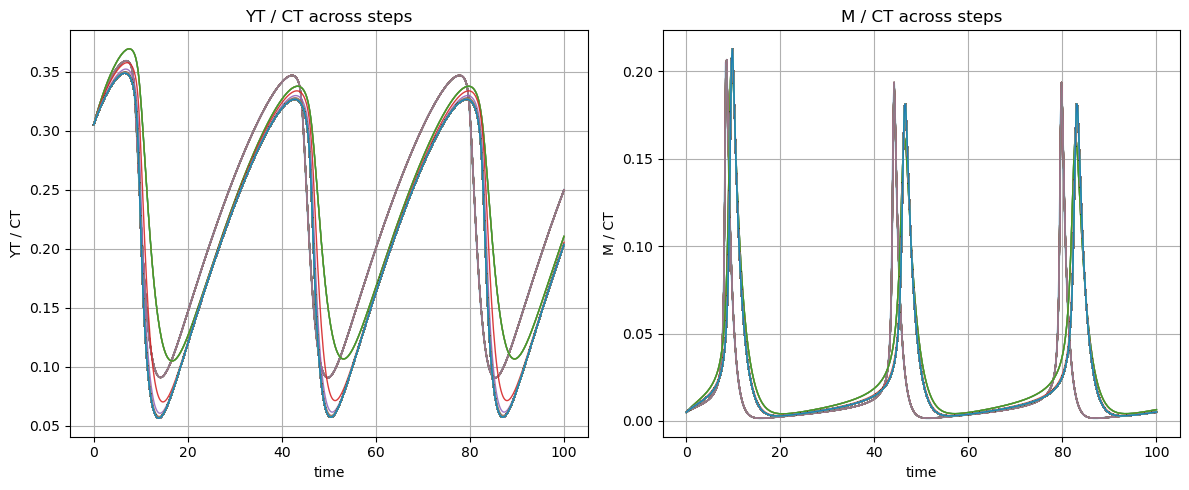

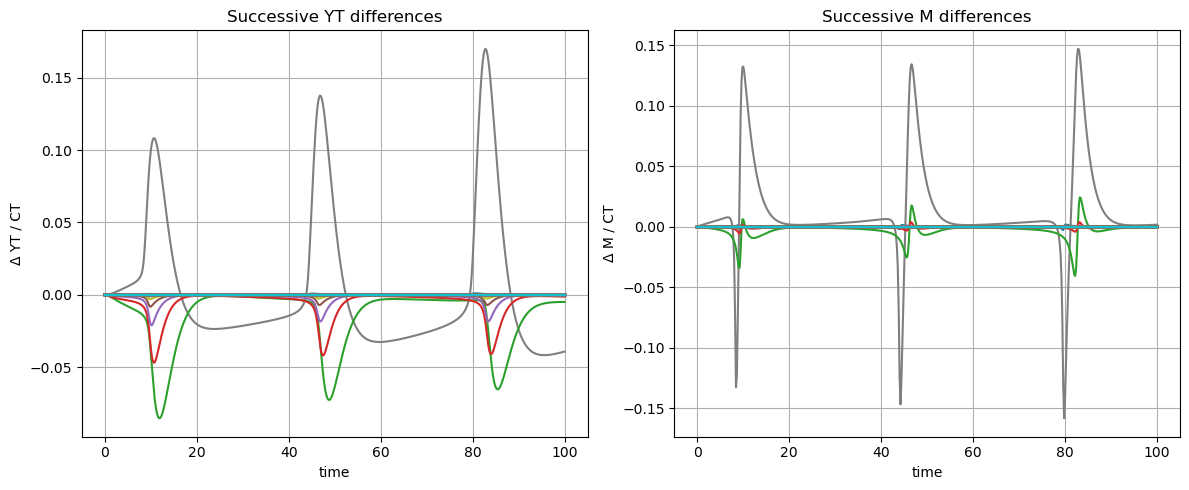

In [2]:
# ----------------------------
# Iterative sloppy-stepping block
# Paste this under your original script
# ----------------------------

import copy
from scipy.integrate import solve_ivp
from numpy.linalg import eigh, svd

# Settings for the iterative procedure
n_steps = 200           # number of sloppy steps to take
delta_target = 0.1    # quadratic rule target (same as your single-step code)
max_logstep = 1
clamp_logstep = 2.0   # clamp per-component log-step magnitude
tol_positive_eig = 1e-30

# re-use compute_obs from your script (or define again if needed)
def compute_obs_from_solution(sol):
    """Given solution.y (6 x m) return YT/CT and M/CT arrays."""
    C2 = sol[0, :]
    CP = sol[1, :]
    pM = sol[2, :]
    M = sol[3, :]
    Y = sol[4, :]
    YP = sol[5, :]
    YT = Y + YP + pM + M
    return YT / p['CT'], M / p['CT']

# helper: compute H for a parameter dict (returns H, eigvals, eigvecs, J_time, t)
def compute_H_for_params(p_local):
    # integrate augmented system just like above but using p_local
    P_local = len(param_names)
    # local augmented rhs wrapper that uses p_local
    def augmented_rhs_local(t, z):
        x = z[:6]
        S_flat = z[6:]
        S = S_flat.reshape((6, P_local), order='F')
        xdot = f_rhs(t, x, p_local)
        A = jacobian_fx(x, p_local)
        df_dh = df_dparam(x, p_local)
        df_dlogh = np.zeros_like(df_dh)
        for j,name in enumerate(param_names):
            df_dlogh[:, j] = p_local[name] * df_dh[:, j]
        Sdot = A.dot(S) + df_dlogh
        return np.concatenate([xdot, Sdot.ravel(order='F')])

    # initial conditions (states same as original)
    z0_local = np.concatenate([y0, np.zeros((6, P_local)).ravel(order='F')])
    t_span_local = (t_span[0], t_span[1])
    t_eval_local = t_eval  # reuse your t_eval if available
    sol = solve_ivp(augmented_rhs_local, t_span_local, z0_local,
                    method='BDF', t_eval=t_eval_local, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Augmented integration failed: " + sol.message)

    # extract J_time (observables = identity -> state sensitivities)
    m_local = sol.t.size
    S_flat_loc = sol.y[6:, :]  # (6*P) x m
    S_time_loc = np.zeros((6, P_local, m_local))
    for i in range(m_local):
        S_time_loc[:, :, i] = S_flat_loc[:, i].reshape((6, P_local), order='F')

    # build W and quadrature weights (reuse your W, q definitions if present)
    # If W or q not in scope, recompute the same way as before:
    Ns_local = 6
    Nc_local = 1
    Tc_local = t_span_local[1] - t_span_local[0]
    sigma_local = 1.0
    W_diag_local = np.ones(Ns_local) * (1.0 / (Nc_local * Ns_local * Tc_local * sigma_local**2))
    W_local = np.diag(W_diag_local)

    # trapezoid q (use sol.t)
    tt = sol.t
    dt_local = np.diff(tt)
    q_local = np.zeros_like(tt)
    if tt.size >= 2:
        q_local[0] = dt_local[0] / 2.0
        q_local[-1] = dt_local[-1] / 2.0
        q_local[1:-1] = 0.5 * (dt_local[:-1] + dt_local[1:])

    # accumulate H
    H_local = np.zeros((P_local, P_local))
    for i in range(m_local):
        J_i = S_time_loc[:, :, i]   # 6 x P
        A_i = J_i.T.dot(W_local).dot(J_i)
        H_local += q_local[i] * A_i

    # eigendecompose
    eigvals_local, eigvecs_local = eigh(H_local)
    eigvals_local = eigvals_local[::-1]
    eigvecs_local = eigvecs_local[:, ::-1]
    return dict(H=H_local, eigvals=eigvals_local, eigvecs=eigvecs_local,
                J_time=S_time_loc, t=sol.t, q=q_local, sol=sol)

# simulate baseline once for reference outputs (already defined simulate_at_params above)
t_base, X_base = simulate_at_params(p, t_eval)
YT_base, M_base = compute_obs(X_base)

# prepare storage
param_history = []
logparam_history = []
eig_history = []
vec_history = []
score_history = []
obs_history = []   # store (YT, M) arrays per step including baseline

# initialize p_current
p_current = dict(p)
param_history.append(copy.deepcopy(p_current))
logparam_history.append(np.log([p_current[name] for name in param_names]))
obs_history.append((YT_base.copy(), M_base.copy()))

print("\nStarting iterative sloppy-stepping (n_steps = {})".format(n_steps))

for step in range(1, n_steps+1):
    print("\n=== Step {:d} ===".format(step))
    # 1) compute H and spectrum at p_current
    res = compute_H_for_params(p_current)
    H = res['H']; eigvals = res['eigvals']; eigvecs = res['eigvecs']
    eig_history.append(eigvals)
    vec_history.append(eigvecs)

    # find smallest positive eigenvalue index (sloppiest)
    pos_idx = np.where(eigvals > tol_positive_eig)[0]
    if pos_idx.size == 0:
        print("No positive eigenvalues found at step", step, " — stopping.")
        break
    sloppy_idx = pos_idx[-1]  # last index is smallest positive
    lam = eigvals[sloppy_idx]
    v = eigvecs[:, sloppy_idx]

    print(f"Chosen sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")

    # compute alpha from quadratic rule (same as before)
    alpha = np.sqrt(delta_target / max(lam, 1e-300))
    alpha = min(alpha, max_logstep)
    dlogh = alpha * v
    dlogh = np.clip(dlogh, -clamp_logstep, clamp_logstep)

    # build candidate parameter dicts
    p_plus = dict(p_current)
    p_minus = dict(p_current)
    for j, name in enumerate(param_names):
        p_plus[name]  = p_current[name] * np.exp(+dlogh[j])
        p_minus[name] = p_current[name] * np.exp(-dlogh[j])

    # simulate baseline at this iteration (for numerical consistency use simulate_at_params)
    t_eval_local = t_eval
    _, X0 = simulate_at_params(p_current, t_eval_local)
    YT0, M0 = compute_obs(X0)

    # simulate both candidates
    _, Xp = simulate_at_params(p_plus, t_eval_local)
    _, Xm = simulate_at_params(p_minus, t_eval_local)
    YTp, Mp = compute_obs(Xp)
    YTm, Mm = compute_obs(Xm)

    # compute integrated square differences and pick sign that changes outputs least
    def integrated_sq_diff_vec(A, B, q_weights):
        return np.sum(q_weights * ((A - B)**2))

    # build trapezoid q over t_eval_local
    tt = t_eval_local
    dt_local = np.diff(tt)
    q_local = np.zeros_like(tt)
    if tt.size >= 2:
        q_local[0] = dt_local[0] / 2.0
        q_local[-1] = dt_local[-1] / 2.0
        q_local[1:-1] = 0.5 * (dt_local[:-1] + dt_local[1:])

    score_plus  = integrated_sq_diff_vec(YT0, YTp, q_local) + integrated_sq_diff_vec(M0, Mp, q_local)
    score_minus = integrated_sq_diff_vec(YT0, YTm, q_local) + integrated_sq_diff_vec(M0, Mm, q_local)

    if score_plus <= score_minus:
        chosen = 'plus'
        p_next = p_plus
        YT_next, M_next = YTp, Mp
        score_chosen = score_plus
    else:
        chosen = 'minus'
        p_next = p_minus
        YT_next, M_next = YTm, Mm
        score_chosen = score_minus

    print(f"Picked direction: {chosen}, alpha: {alpha:.4g}, integrated-sq-change: {score_chosen:.3e}")
    # log differences
    diff_params = {name: (p_next[name] - p_current[name]) for name in param_names}
    print("parameter difference (additive):", diff_params)

    # store histories
    param_history.append(copy.deepcopy(p_next))
    logparam_history.append(np.log([p_next[name] for name in param_names]))
    score_history.append(score_chosen)
    obs_history.append((YT_next.copy(), M_next.copy()))

    # update p_current for next iteration
    p_current = p_next

# Convert histories to arrays for plotting
n_recorded = len(param_history)
logparam_mat = np.vstack(logparam_history)  # shape (n_recorded, P)

# ========== Plotting ==========
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Colors: use default matplotlib cycling (do not specify explicit colors)
steps_idx = np.arange(n_recorded)

# 1) Overlay of YT curves and M curves for all recorded steps
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i,(YT_i, M_i) in enumerate(obs_history):
    label = 'step 0' if i==0 else f'step {i}'
    plt.plot(t_eval, YT_i, label=label, lw=1.3 if i==0 else 1.0, alpha=0.9)
plt.xlabel('time'); plt.ylabel('YT / CT'); plt.title('YT / CT across steps'); plt.grid(True)
if n_recorded <= 20:
    plt.legend()

plt.subplot(1,2,2)
for i,(YT_i, M_i) in enumerate(obs_history):
    label = 'step 0' if i==0 else f'step {i}'
    plt.plot(t_eval, M_i, label=label, lw=1.3 if i==0 else 1.0, alpha=0.9)
plt.xlabel('time'); plt.ylabel('M / CT'); plt.title('M / CT across steps'); plt.grid(True)
if n_recorded <= 20:
    plt.legend()
plt.tight_layout()
plt.show()

# 2) Differences between successive steps (YT and M)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(1, n_recorded):
    Yprev, Mprev = obs_history[i-1]
    Ycurr, Mcurr = obs_history[i]
    diffY = Ycurr - Yprev
    plt.plot(t_eval, diffY, label=f'{i-1}→{i}')
plt.xlabel('time'); plt.ylabel('Δ YT / CT'); plt.title('Successive YT differences'); plt.grid(True)
if n_recorded <= 20:
    plt.legend()

plt.subplot(1,2,2)
for i in range(1, n_recorded):
    Yprev, Mprev = obs_history[i-1]
    Ycurr, Mcurr = obs_history[i]
    diffM = Mcurr - Mprev
    plt.plot(t_eval, diffM, label=f'{i-1}→{i}')
plt.xlabel('time'); plt.ylabel('Δ M / CT'); plt.title('Successive M differences'); plt.grid(True)
if n_recorded <= 20:
    plt.legend()
plt.tight_layout()
plt.show()

# 3) Trajectory in log-parameter space visualized by PCA -> 3D
# center the logparam matrix and take first 3 principal components via SVD
Xc = logparam_mat - logparam_mat.mean(axis=0)
U, svals, Vt = svd(Xc, full_matrices=False)
# project onto first 3 P


In [3]:
# ----------------------------
# Trajectory visualization helpers
# Requires: numpy, matplotlib, mpl_toolkits.mplot3d, scipy (svd)
# Paste under your existing script (after param_history is available)
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from numpy.linalg import svd

def build_logparam_matrix(param_history, param_names):
    """Return (n_steps x P) matrix of log-parameters."""
    P = len(param_names)
    n = len(param_history)
    L = np.zeros((n, P))
    for i, pd in enumerate(param_history):
        use_log = True
        if use_log:
            L[i, :] = np.log([pd[name] for name in param_names])
        else:
            L[i, :] = [pd[name] for name in param_names]
    return L



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as colors

# --- assume these already exist:
# logparam_mat  : shape (n_steps, n_params)
# param_names   : list of parameter names
# coords        : shape (n_steps, 3)
# top3_names    : list of 3 names

n_steps = logparam_mat.shape[0]
n_pts = coords.shape[0]

# choose about 10 labels (or fewer if n_steps < 10)
n_labels = min(10, max(1, n_steps))
label_indices = np.unique(np.round(np.linspace(0, n_steps - 1, n_labels)).astype(int))

# colormap & normalization
cmap = cm.get_cmap('viridis', n_steps)
norm = colors.Normalize(vmin=0, vmax=n_steps - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# ----------------------------
# Single 3D trajectory plot (no arrows)
# ----------------------------
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# draw colored line segments
for i in range(n_pts - 1):
    c = cmap(norm(i))
    ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2], '-', color=c, alpha=0.9, linewidth=1.2)

# scatter points with gradient color
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=np.arange(n_pts), cmap=cmap, norm=norm, s=40)

# white labels on selected steps
for k in label_indices:
    ax.text(coords[k, 0], coords[k, 1], coords[k, 2], f'{k}', fontsize=9, color='green', weight='bold')

ax.set_xlabel(top3_names[0])
ax.set_ylabel(top3_names[1])
ax.set_zlabel(top3_names[2])
ax.set_title('3D trajectory of top-3 most-varying log-parameters')

# colorbar for step index
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.08)
cbar.set_label('Step index')

plt.tight_layout()
plt.show()

# ----------------------------
# Combined Parallel Coordinates + 3D Trajectory (no arrows)
# ----------------------------
fig = plt.figure(figsize=(13, 5))

# left: parallel coordinates
ax1 = fig.add_subplot(1, 2, 1)
xs = np.arange(len(param_names))
for i in range(n_steps):
    ax1.plot(xs, logparam_mat[i, :], '-o', color=cmap(norm(i)), alpha=0.9, markersize=3, linewidth=0.9)

# annotate only selected steps on the parallel coordinates
for k in label_indices:
    y = logparam_mat[k, 0]
    ax1.text(xs[0] - 0.08, y, f'{k}', fontsize=8, verticalalignment='center', color='white', weight='bold')

ax1.set_xticks(xs)
ax1.set_xticklabels(param_names, rotation=45, ha='right')
ax1.set_ylabel('log(param)')
ax1.set_title('Parallel coordinates (all params)')
ax1.grid(True, alpha=0.35)

# right: 3D trajectory
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for i in range(n_pts - 1):
    ax2.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2], '-', color=cmap(norm(i)), alpha=0.9, linewidth=1.0)

ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=np.arange(n_pts), cmap=cmap, norm=norm, s=32)

# white numeric labels
for k in label_indices:
    ax2.text(coords[k, 0], coords[k, 1], coords[k, 2], f'{k}', fontsize=8, color='green', weight='bold')

ax2.set_xlabel(top3_names[0])
ax2.set_ylabel(top3_names[1])
ax2.set_zlabel(top3_names[2])
ax2.set_title('Top-3 params 3D trajectory')

# shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.47, 0.18, 0.015, 0.62])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Step index')

fig.subplots_adjust(left=0.06, right=0.92, wspace=0.38)
plt.show()


NameError: name 'coords' is not defined

In [ ]:
# two-line snippet
vals = [np.log(p['k3_CT']) for p in param_history]  # or just p['k3_CT'] for linear space
print("k3_CT (log) across steps:", np.round(vals, 6))

vals = [np.log(p['k8_minusP']) for p in param_history]  # or just p['k8_minusP'] for linear space
print("k8_minusP (log) across steps:", np.round(vals, 6))

vals = [np.log(p['k9']) for p in param_history]  # or just p['k9'] for linear space
print("k9 (log) across steps:", np.round(vals, 6))


keys = list(param_history[0].keys())
v1 = np.array([param_history[0][k] for k in keys])
v2 = np.array([param_history[n_steps-1][k] for k in keys])

# compute absolute differences
diff = np.abs(v2 - v1)

# find indices of top 3 changes
top3_idx = np.argsort(diff)[-3:][::-1]

print("Top 3 coordinates with largest change:\n")
for i in top3_idx:
    print(f"{keys[i]}:")
    print(f"  Step 0: {v1[i]:.6g}")
    print(f"  Step 1: {v2[i]:.6g}")
    print(f"  Δ (abs): {diff[i]:.6g}\n")


k3_CT (log) across steps: [ 5.298317  6.298309  7.298308  8.298308  9.298308 10.298307 11.298307
 12.298307 13.298307 14.298307 13.298307 14.298307 13.298307 14.298307
 13.298307 14.298307 13.298307 14.298307 13.298307 14.298307 13.298307
 14.298307 13.298307 14.298307 13.298307 14.298307 13.298307 14.298307
 14.298306 15.298306 16.298306 17.298306 16.298306 16.298306 16.298306
 16.298307 16.298307 15.298307 16.298307 16.298307 15.298307 15.298307
 15.298307 15.298307 15.298307 14.298307 15.298307 14.298307 15.298307
 14.298307 15.298307 15.298307 14.298307 15.298307 14.298307 15.298307
 14.298307 15.298307 14.298307 15.298307 14.298307 15.298307 15.298307
 16.298307 15.298307 16.298307 16.298307 16.298307 15.298307 16.298307
 16.298307 17.298307 16.298307 17.298307 17.298307 17.298307 16.298307
 15.298307 15.298307 16.298307 16.298307 16.298307 17.298307 17.298307
 18.298307 18.298307 18.298307 18.298307 18.298307 18.298307 18.298307
 18.298307 18.298307 18.298307 18.298307 18.298307 